In [93]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from scipy import *

# 1-qubit Open Quantum System Simulation

### Parameter, Operator, & Hamiltonian Initialization

In [94]:
### Define sigma_(x,y,z) ops. |0x0|, |1x1|
sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)
identity = np.array([[1,0],[0,1]], dtype=complex)
ket0 = np.array([[1,0],[0,0]], dtype=complex) #|0x0|
ket1 = np.array([[0,0],[0,1]], dtype=complex) #|1x1|

#parameters
omega = 2*np.pi #oscillation freq
delta = 1
gamma_phase = .1 #phase damping rate
gamma_amp = .1 #amplitude damping rate
gamma_flip = .1 #bit flip rate
gammma_depolarize = .1 #depolarization rate
times = np.linspace(0,5,1000) #times we integrate over

#string list of the channel, this is referenced when calling the simulate method
channels = ['bit_flip', 'amplitude_damping', 'phase_damping', 'depolarization']

#Hamiltonian def
H = -.5*delta*sigma_z + .5*omega*sigma_x


### Kraus operators

In [95]:
#bit flip (K0 = sqrt(1-p)*I; K1 = sqrt(p)*X)
def bit_flip(p):
    K0 = np.sqrt(1-p)*identity
    K1 = np.sqrt(p)*sigma_x
    return [K0,K1]
#amplitude damping channel (defined by matrices its easier that way)
def amp_damp(p):
    K0 = np.array([[1,0], [0, np.sqrt(1-p)]], dtype = complex)
    K1 = np.array([[0,np.sqrt(p)], [0, 0]], dtype = complex)
    return [K0,K1]
#phase damping (K0 = sqrt(1-p)*I; K1 = sqrt(p)*Z)
def phase_damp(p):
    K0 = np.sqrt(1-p)*identity
    K1 = np.sqrt(p)*sigma_z
    return [K0,K1]
#depolarizing (K0 = sqrt(1-.25p)*I; K1 = sqrt(p/4)*X; K2 = sqrt(p/4)*Y; K3 = sqrt(p/4)*Z )
def depolarize(p):
    K0 = np.sqrt(1-(.25*p))*identity
    K1 = np.sqrt(p/4)*sigma_x
    K2 = np.sqrt(p/4)*sigma_y
    K3 = np.sqrt(p/4)*sigma_z
    return [K0, K1, K2, K3]


In [96]:
# Calculate the effect of the Kraus operators on density matrix rho
def kraus_compute(rho, op_arr):
    rho_f = np.zeros_like(rho, dtype=complex)
    for K in op_arr:
        rho_f += K @ rho @ K.conjugate().T #compute K*rho*Kdag for each operator in a channel
    return rho_f


### Simulation

In [97]:
#cast to Qobj to turn into qutip object, pass through qutip mesolve
def simulate(channel, gamma, rho0): #sim method takes a string representing the channel, a float representing the value of gamma/prob for a channel, and the system's initial hamiltonian
    if channel == channels[0]:
        operators = bit_flip(gamma)
        rho_f = kraus_compute(rho0, operators)
        return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmax()]) 
    elif channel == channels[1]:
        operators = amp_damp(gamma)
        rho_f = kraus_compute(rho0, operators)
        return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmap()]) 
    elif channel == channels[2]:
        operators = phase_damp(gamma)
        rho_f = kraus_compute(rho0, operators)
        return master_helper(rho_f, H, times, [np.sqrt(gamma)*sigmaz()])
    elif channel == channels[3]:
        operators = depolarize(gamma)
        rho_f = kraus_compute(rho0, operators)
        return master_helper(rho_f, H, times, [np.sqrt(gamma/4)*sigmax(),np.sqrt(gamma/4)*sigmay(), np.sqrt(gamma/4)*sigmaz()]) 
    else:
        return "Error" 

def master_helper(rho, H, times, op):
    H = Qobj(H) #cast Hamiltonian to qutip object
    rho = Qobj(rho) #cast density matrix to qutip object
    result = mesolve(H, rho, times, op, [])
    return result 

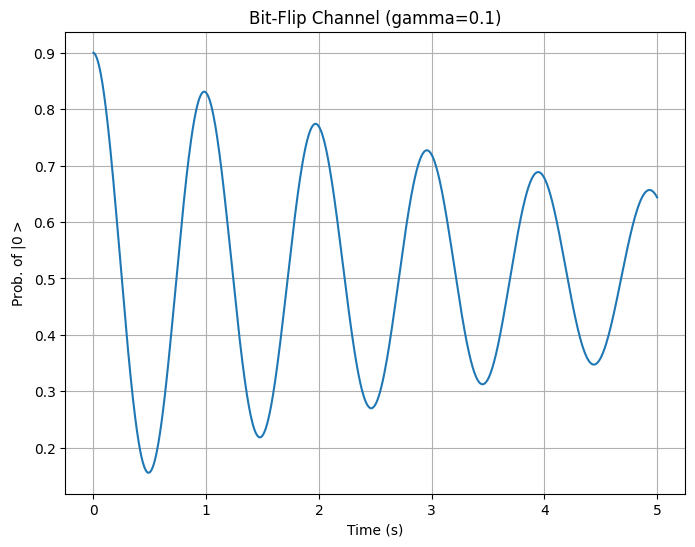

In [98]:
result = simulate('bit_flip',gamma_flip, ket0)
excited_proj = basis(2,0) * basis(2,0).dag()
excited_pop = expect(excited_proj, result.states)
plt.figure(figsize=(8,6))
plt.plot(result.times, excited_pop)
plt.xlabel("Time (s)")
plt.ylabel(f"Prob. of $|0 >$")
plt.title("Bit-Flip Channel (gamma=0.1)")
plt.grid()

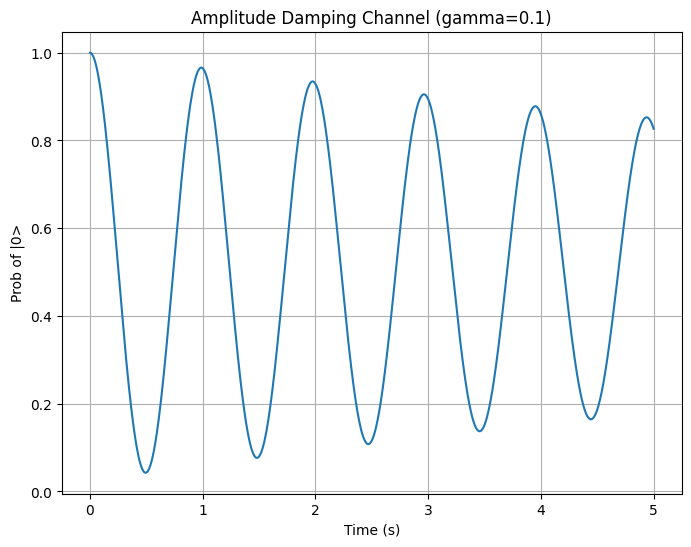

In [99]:
result = simulate('amplitude_damping',gamma_amp, ket0)
excited_proj = basis(2,0) * basis(2,0).dag()
excited_pop = expect(excited_proj, result.states)
plt.figure(figsize=(8,6))
plt.plot(result.times, excited_pop)
plt.xlabel("Time (s)")
plt.ylabel("Prob of |0>")
plt.title("Amplitude Damping Channel (gamma=0.1)")
plt.grid()

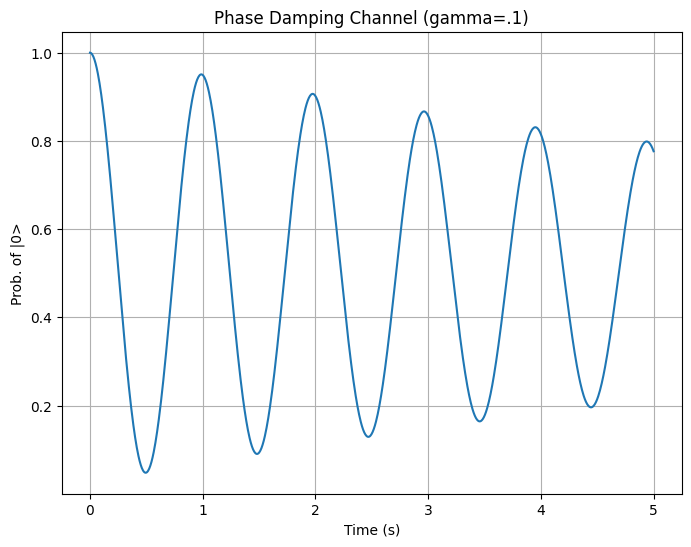

In [100]:
result = simulate('phase_damping',gamma_phase, ket0)
excited_proj = basis(2,0) * basis(2,0).dag()
excited_pop = expect(excited_proj, result.states)
plt.figure(figsize=(8,6))
plt.plot(result.times, excited_pop)
plt.xlabel("Time (s)")
plt.ylabel("Prob. of |0>")
plt.title("Phase Damping Channel (gamma=.1)")
plt.grid()

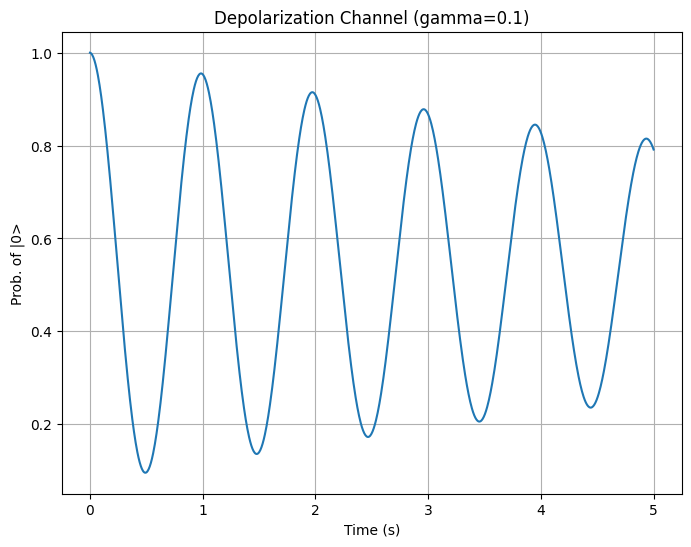

In [101]:
result = simulate('depolarization',gammma_depolarize, ket0)
excited_proj = basis(2,0) * basis(2,0).dag()
excited_pop = expect(excited_proj, result.states)
plt.figure(figsize=(8,6))
plt.plot(result.times, excited_pop)
plt.xlabel("Time (s)")
plt.ylabel("Prob. of |0>")
plt.title("Depolarization Channel (gamma=0.1)")
plt.grid()

- Include T1, T2 fits, should see expected behavior/relationship from slides (boundary conditions should be satisfied) 2e^(-t/T1) -1 for <sigma_z>. (they use |1> as the excited state). always start in excited state for for T1 experiment
- Extend simulation to 2/3 qubit case
- convert to pytorch tensors?

<Figure size 1200x1000 with 0 Axes>

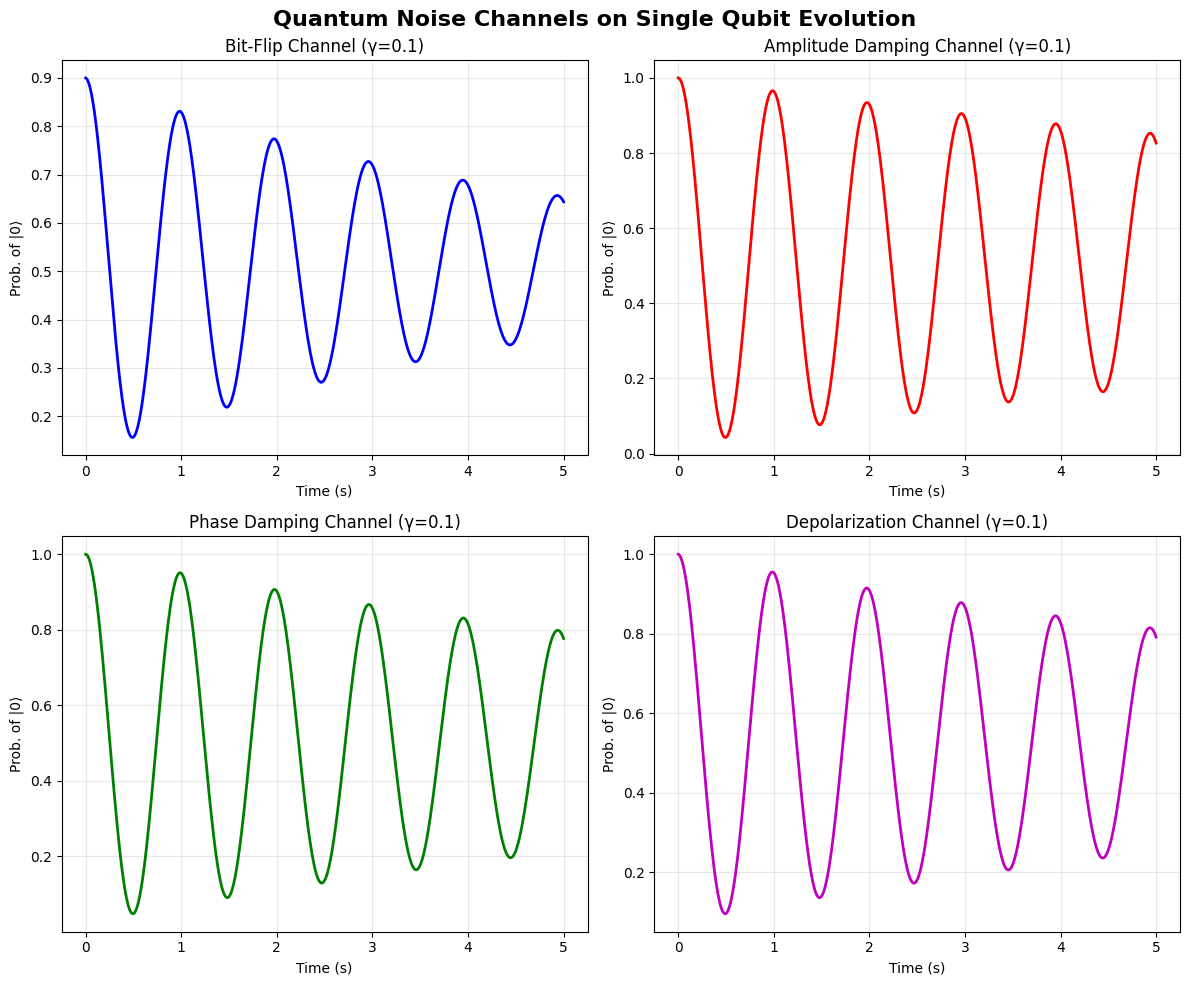

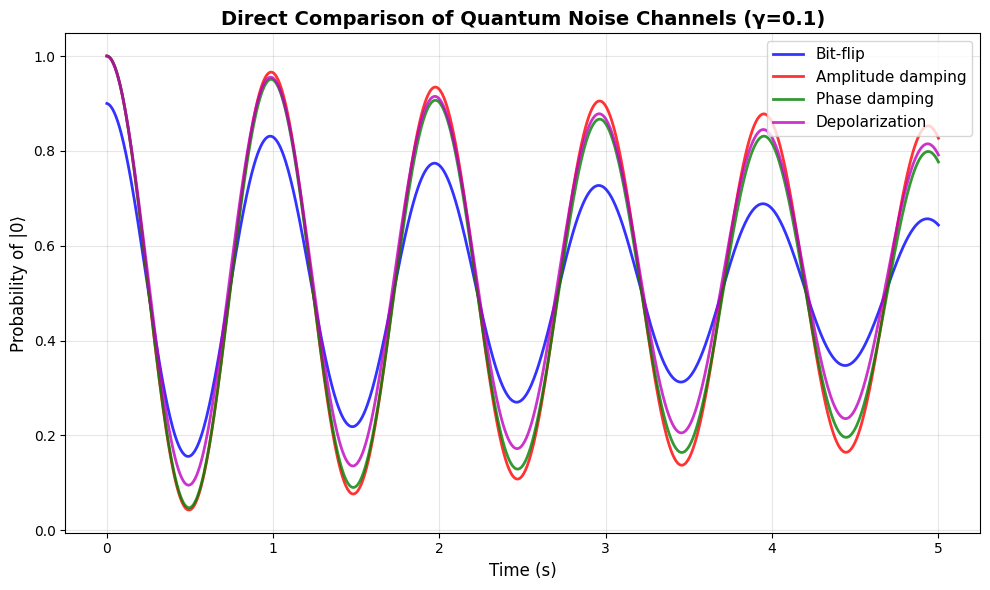

In [102]:
# Combined plot showing all four quantum noise channels
plt.figure(figsize=(12, 10))

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Define the projection operator for |0⟩ state probability
excited_proj = basis(2,0) * basis(2,0).dag()

# Plot 1: Bit-flip channel
result_bf = simulate('bit_flip', gamma_flip, ket0)
excited_pop_bf = expect(excited_proj, result_bf.states)
axes[0,0].plot(result_bf.times, excited_pop_bf, 'b-', linewidth=2)
axes[0,0].set_xlabel("Time (s)")
axes[0,0].set_ylabel("Prob. of |0⟩")
axes[0,0].set_title("Bit-Flip Channel (γ=0.1)")
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Amplitude damping channel
result_ad = simulate('amplitude_damping', gamma_amp, ket0)
excited_pop_ad = expect(excited_proj, result_ad.states)
axes[0,1].plot(result_ad.times, excited_pop_ad, 'r-', linewidth=2)
axes[0,1].set_xlabel("Time (s)")
axes[0,1].set_ylabel("Prob. of |0⟩")
axes[0,1].set_title("Amplitude Damping Channel (γ=0.1)")
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Phase damping channel
result_pd = simulate('phase_damping', gamma_phase, ket0)
excited_pop_pd = expect(excited_proj, result_pd.states)
axes[1,0].plot(result_pd.times, excited_pop_pd, 'g-', linewidth=2)
axes[1,0].set_xlabel("Time (s)")
axes[1,0].set_ylabel("Prob. of |0⟩")
axes[1,0].set_title("Phase Damping Channel (γ=0.1)")
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Depolarization channel
result_dep = simulate('depolarization', gammma_depolarize, ket0)
excited_pop_dep = expect(excited_proj, result_dep.states)
axes[1,1].plot(result_dep.times, excited_pop_dep, 'm-', linewidth=2)
axes[1,1].set_xlabel("Time (s)")
axes[1,1].set_ylabel("Prob. of |0⟩")
axes[1,1].set_title("Depolarization Channel (γ=0.1)")
axes[1,1].grid(True, alpha=0.3)

# Add an overall title and adjust layout
fig.suptitle('Quantum Noise Channels on Single Qubit Evolution', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Make room for the main title
plt.show()

# Optional: Create an overlaid comparison plot
plt.figure(figsize=(10, 6))

# Plot all channels on the same axes for direct comparison
plt.plot(result_bf.times, excited_pop_bf, 'b-', linewidth=2, label='Bit-flip', alpha=0.8)
plt.plot(result_ad.times, excited_pop_ad, 'r-', linewidth=2, label='Amplitude damping', alpha=0.8)
plt.plot(result_pd.times, excited_pop_pd, 'g-', linewidth=2, label='Phase damping', alpha=0.8)
plt.plot(result_dep.times, excited_pop_dep, 'm-', linewidth=2, label='Depolarization', alpha=0.8)

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Probability of |0⟩", fontsize=12)
plt.title("Direct Comparison of Quantum Noise Channels (γ=0.1)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()